# Ablation Figures for Paper

This notebook generates publication-ready figures for two ablations:
1. **Component Loss Weight ($\lambda_{comp}$)** - Line plot showing I2T, T2I, Group vs. lambda
2. **Loss Function Configuration** - Table with checkmarks showing different loss combinations

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add ablations directory to path
sys.path.insert(0, '../ablations')

from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Set up plotting style
setup_plotting_style()

# Configure tueplots for ICML
from tueplots import figsizes, fontsizes, fonts
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

## 1. Component Loss Weight Ablation ($\lambda_{comp}$)

In [3]:
# =============================================================================
# CONFIGURATION - Component Lambda Ablation
# =============================================================================

COMP_LAMBDA_MODELS = {
    "λ=0.1": {
        "csv_path": "../evaluation/ablations/03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.1.csv",
        "is_baseline": False,
        "lambda_value": 0.1
    },
    "λ=0.25": {
        "csv_path": "../evaluation/ablations/03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.25_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.25.csv",
        "is_baseline": False,
        "lambda_value": 0.25
    },
    "λ=0.5": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "lambda_value": 0.5
    },
    "λ=0.75": {
        "csv_path": "../evaluation/ablations/04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.75_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.75.csv",
        "is_baseline": False,
        "lambda_value": 0.75
    },
    "λ=1.0": {
        "csv_path": "../evaluation/ablations/04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_1.0.csv",
        "is_baseline": False,
        "lambda_value": 1.0
    },
}

# Load all metrics
all_metrics_df = load_all_models_all_metrics(COMP_LAMBDA_MODELS, METRICS, checkpoint_step=None)

# Extract summary columns
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
comp_summary_df = all_metrics_df[summary_cols].copy()
comp_summary_df['Average'] = comp_summary_df.mean(axis=1)

print("Component Lambda Ablation Results:")
display((comp_summary_df * 100).round(1))

Loading λ=0.1...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ=0.25...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ=0.5...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ=0.75...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ=1.0...
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (19): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VL_CheckList', 'VisMin', 'Winoground']
Component Lambda Ablation Results:


,I2T,T2I,Group,Average
Model,,,,
λ=0.1,62.5,40.2,23.8,42.2
λ=0.25,62.4,41.1,24.7,42.7
λ=0.5,63.4,41.6,25.4,43.4
λ=0.75,62.9,40.9,24.6,42.8
λ=1.0,62.9,40.3,24.7,42.6


/tmp/ipykernel_3285896/1079495154.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


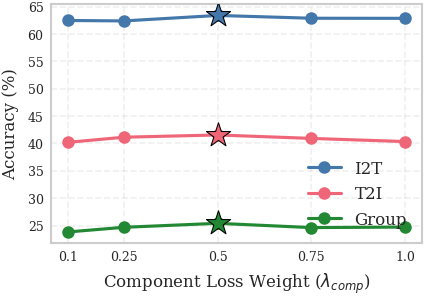


Baseline (λ=0.5) marked with ★


In [4]:
# =============================================================================
# FIGURE 1: Component Loss Weight Line Plot
# =============================================================================

# Extract lambda values and scores
lambda_values = [COMP_LAMBDA_MODELS[m]['lambda_value'] for m in comp_summary_df.index]
baseline_idx = [i for i, m in enumerate(comp_summary_df.index) if COMP_LAMBDA_MODELS[m].get('is_baseline', False)][0]

# Colors for each metric
colors = {
    'I2T': '#4477AA',   # Blue
    'T2I': '#EE6677',   # Red  
    'Group': '#228833', # Green
    'Average': '#CCBB44'  # Yellow
}

# Create figure
fig_width = plt.rcParams["figure.figsize"][0] * 0.45  # Half width for single column
fig, ax = plt.subplots(figsize=(fig_width, 2.2))

# Plot each metric
for metric in ['I2T', 'T2I', 'Group']:
    scores = comp_summary_df[metric].values * 100
    ax.plot(lambda_values, scores, 'o-', color=colors[metric], 
            label=metric, linewidth=1.5, markersize=5)
    
    # Mark baseline with star
    ax.scatter([lambda_values[baseline_idx]], [scores[baseline_idx]], 
               marker='*', s=150, color=colors[metric], zorder=10, edgecolor='black', linewidth=0.5)

# Styling
ax.set_xlabel(r'Component Loss Weight ($\lambda_{comp}$)')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(lambda_values)
ax.set_xticklabels([f'{v}' for v in lambda_values])
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

# Y-axis limits with some padding
y_min = comp_summary_df[['I2T', 'T2I', 'Group']].min().min() * 100 - 2
y_max = comp_summary_df[['I2T', 'T2I', 'Group']].max().max() * 100 + 2
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('../paper_figures/ablation_comp_lambda_line.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nBaseline (λ=0.5) marked with ★")

## 2. Loss Function Configuration Ablation

In [ ]:
# =============================================================================
# CONFIGURATION - Loss Function Ablation
# =============================================================================

# Define all the loss configurations based on user's specification:
# global_neg: Use hard negatives for global (full caption) loss
# units: Use component/unit captions
# unit_neg: Use hard negatives for component/unit loss
LOSS_CONFIG_MODELS = {
    # CLIP FT: No negatives, no units
    "CLIP Fine-tuning": {
        "csv_path": "../evaluation/ablations/21-Jan_coco_without_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_ft.csv",
        "global_neg": False,
        "units": False,
        "unit_neg": False,
        "is_baseline": False,
        "description": "Standard CLIP fine-tuning"
    },
    
    # NegCLIP: Only global negatives, no units
    "NegCLIP": {
        "csv_path": "../evaluation/negclip_coco_vitb32.csv",
        "global_neg": True,
        "units": False,
        "unit_neg": False,
        "is_baseline": False,
        "description": "NegCLIP (global negatives only)"
    },
    
    # CLIP + CLIP: Units without any negatives
    "CLIP + NegCLIP": {
        "csv_path": "../evaluation/ablations/09-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_comp_baseline.csv",
        "global_neg": False,
        "units": True,
        "unit_neg": True,
        "is_baseline": False,
        "description": "CLIP global + NegCLIP component"
    },
    
    # CLIP + NegCLIP: Units with unit negatives but no global negatives
    "CLIP + CLIP": {
        "csv_path": "../evaluation/ablations/09-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_clip_comp_clip.csv",
        "global_neg": False,
        "units": True,
        "unit_neg": True,
        "is_baseline": False,
        "description": "CLIP global + CLIP"
    },
    
    # NegCLIP + CLIP: Global negatives + units without unit negatives
    "NegCLIP + CLIP": {
        "csv_path": "../evaluation/ablations/21-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_clip_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_negclip_w_comp.csv",
        "global_neg": True,
        "units": True,
        "unit_neg": False,
        "is_baseline": False,
        "description": "NegCLIP global + CLIP component"
    },
    
    # CS-CLIP: Full method - global negatives + units + unit negatives
    "CS-CLIP": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "global_neg": True,
        "units": True,
        "unit_neg": True,
        "is_baseline": True,
        "description": "Full CS-CLIP (NegCLIP global + NegCLIP component)"
    },
}

# Load all metrics
loss_metrics_df = load_all_models_all_metrics(LOSS_CONFIG_MODELS, METRICS, checkpoint_step=None)

# Extract summary columns
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in loss_metrics_df.columns]
loss_summary_df = loss_metrics_df[summary_cols].copy()
loss_summary_df['Average'] = loss_summary_df.mean(axis=1)

print("Loss Function Ablation Results:")
display((loss_summary_df * 100).round(1))

Loading CLIP Fine-tuning...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading NegCLIP...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading CLIP + NegCLIP...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading CLIP + CLIP...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading NegCLIP + CLIP...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading CS-CLIP...
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (18): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VisMin', 'Winoground']
Loss Function Ablation Results:


,I2T,T2I,Group,Average
Model,,,,
CLIP Fine-tuning,52.5,41.3,24.5,39.4
NegCLIP,59.8,40.2,23.0,41.0
CLIP + NegCLIP,57.2,40.8,25.7,41.2
CLIP + CLIP,52.4,41.5,25.6,39.8
NegCLIP + CLIP,60.9,40.4,24.8,42.1
CS-CLIP,62.5,41.6,25.4,43.2


In [6]:
# =============================================================================
# FIGURE 2: Loss Configuration Table with Checkmarks
# =============================================================================

# Create table data
table_data = []
model_order = ["NegCLIP", "CLIP + CLIP", "CLIP + NegCLIP", "NegCLIP + CLIP", "CS-CLIP"]

for model in model_order:
    if model in LOSS_CONFIG_MODELS and model in loss_summary_df.index:
        cfg = LOSS_CONFIG_MODELS[model]
        row = {
            'Model': model,
            'Global Neg.': '✓' if cfg['global_neg'] else '✗',
            'Units': '✓' if cfg['units'] else '✗',
            'Unit Neg.': '✓' if cfg['unit_neg'] else '✗',
            'I2T': f"{loss_summary_df.loc[model, 'I2T'] * 100:.1f}",
            'T2I': f"{loss_summary_df.loc[model, 'T2I'] * 100:.1f}",
            'Group': f"{loss_summary_df.loc[model, 'Group'] * 100:.1f}",
        }
        table_data.append(row)

table_df = pd.DataFrame(table_data)
print("\nLoss Configuration Table:")
display(table_df)


Loss Configuration Table:


,Model,Global Neg.,Units,Unit Neg.,I2T,T2I,Group
0,NegCLIP,✓,✗,✗,59.8,40.2,23.0
1,CLIP + CLIP,✗,✓,✓,52.4,41.5,25.6
2,CLIP + NegCLIP,✗,✓,✓,57.2,40.8,25.7
3,NegCLIP + CLIP,✓,✓,✗,60.9,40.4,24.8
4,CS-CLIP,✓,✓,✓,62.5,41.6,25.4


In [7]:
# =============================================================================
# Generate LaTeX Table with Checkmarks
# =============================================================================

def make_latex_loss_table(table_df, model_configs, caption="", label=""):
    """Generate LaTeX table with checkmarks for loss configuration ablation."""
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(f"  \\caption{{{caption}}}")
    lines.append(f"  \\label{{{label}}}")
    lines.append(r"  \begin{tabular}{lcccrrr}")
    lines.append(r"    \toprule")
    lines.append(r"    Model & Global Neg. & Units & Unit Neg. & I2T & T2I & Group \\")
    lines.append(r"    \midrule")
    
    for _, row in table_df.iterrows():
        model = row['Model']
        cfg = model_configs.get(model, {})
        is_baseline = cfg.get('is_baseline', False)
        
        # Format checkmarks
        global_neg = r"\cmark" if row['Global Neg.'] == '✓' else r"\xmark"
        units = r"\cmark" if row['Units'] == '✓' else r"\xmark"
        unit_neg = r"\cmark" if row['Unit Neg.'] == '✓' else r"\xmark"
        
        # Format model name
        model_fmt = model
        if is_baseline:
            model_fmt = r"\textbf{" + model + r"}"
        
        # Format scores (bold best, underline baseline)
        i2t = row['I2T']
        t2i = row['T2I']
        group = row['Group']
        
        if is_baseline:
            i2t = r"\textbf{" + i2t + r"}"
            t2i = r"\textbf{" + t2i + r"}"
            group = r"\textbf{" + group + r"}"
        
        lines.append(f"    {model_fmt} & {global_neg} & {units} & {unit_neg} & {i2t} & {t2i} & {group} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

latex_table = make_latex_loss_table(
    table_df, 
    LOSS_CONFIG_MODELS,
    caption="Loss function ablation. Global Neg. = hard negatives for full captions, Units = component captions, Unit Neg. = hard negatives for components. Best (CS-CLIP) in bold.",
    label="tab:ablation_loss"
)

print("="*60)
print("LATEX TABLE (requires \\usepackage{pifont} for \\cmark and \\xmark)")
print("Add to preamble: \\newcommand{\\cmark}{\\ding{51}}")
print("                 \\newcommand{\\xmark}{\\ding{55}}")
print("="*60)
print(latex_table)

LATEX TABLE (requires \usepackage{pifont} for \cmark and \xmark)
Add to preamble: \newcommand{\cmark}{\ding{51}}
                 \newcommand{\xmark}{\ding{55}}
\begin{table}[t]
  \centering
  \small
  \caption{Loss function ablation. Global Neg. = hard negatives for full captions, Units = component captions, Unit Neg. = hard negatives for components. Best (CS-CLIP) in bold.}
  \label{tab:ablation_loss}
  \begin{tabular}{lcccrrr}
    \toprule
    Model & Global Neg. & Units & Unit Neg. & I2T & T2I & Group \\
    \midrule
    NegCLIP & \cmark & \xmark & \xmark & 59.8 & 40.2 & 23.0 \\
    CLIP + CLIP & \xmark & \cmark & \cmark & 52.4 & 41.5 & 25.6 \\
    CLIP + NegCLIP & \xmark & \cmark & \cmark & 57.2 & 40.8 & 25.7 \\
    NegCLIP + CLIP & \cmark & \cmark & \xmark & 60.9 & 40.4 & 24.8 \\
    \textbf{CS-CLIP} & \cmark & \cmark & \cmark & \textbf{62.5} & \textbf{41.6} & \textbf{25.4} \\
    \bottomrule
  \end{tabular}
\end{table}


/tmp/ipykernel_3285896/2657662842.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_3285896/2657662842.py:69: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.savefig('../paper_figures/ablation_loss_table.pdf', bbox_inches='tight', dpi=300)
/tmp/ipykernel_3285896/2657662842.py:69: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  plt.savefig('../paper_figures/ablation_loss_table.pdf', bbox_inches='tight', dpi=300)
/tmp/ipykernel_3285896/2657662842.py:69: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.savefig('../paper_figures/ablation_loss_table.pdf', bbox_inches='tight', dpi=300)
/tmp/ipykernel_3285896/2657662842.py:69: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  plt.savefig('../paper_figures/ablation_loss_table.pdf', bbox_inches='tight', dpi=300)
/mnt/lustre/work/oh/owl336/.conda/py-311-pytorch/lib/python3.11/si

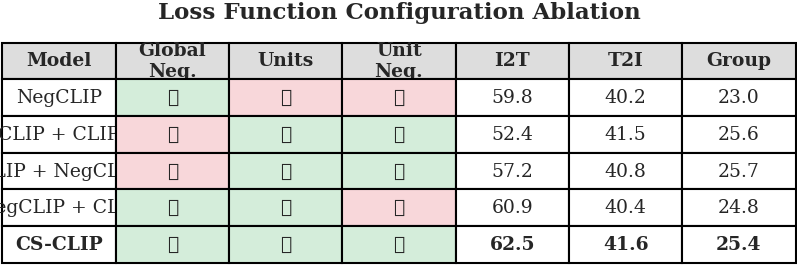

In [8]:
# =============================================================================
# FIGURE 2B: Visual Table as Figure (matplotlib)
# =============================================================================

fig, ax = plt.subplots(figsize=(5.5, 2.0))
ax.axis('off')

# Colors
check_color = '#228833'  # Green for checkmark
cross_color = '#CC3311'  # Red for cross
header_color = '#DDDDDD'

# Table columns
col_labels = ['Model', 'Global\nNeg.', 'Units', 'Unit\nNeg.', 'I2T', 'T2I', 'Group']

# Build cell text and colors
cell_text = []
cell_colors = []

for _, row in table_df.iterrows():
    row_text = [
        row['Model'],
        row['Global Neg.'],
        row['Units'],
        row['Unit Neg.'],
        row['I2T'],
        row['T2I'],
        row['Group']
    ]
    cell_text.append(row_text)
    
    # Color cells based on check/cross
    row_colors = ['white']  # Model name
    for val in [row['Global Neg.'], row['Units'], row['Unit Neg.']]:
        if val == '✓':
            row_colors.append('#d4edda')  # Light green
        else:
            row_colors.append('#f8d7da')  # Light red
    row_colors.extend(['white', 'white', 'white'])  # Scores
    cell_colors.append(row_colors)

# Create table
table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    colColours=[header_color] * len(col_labels),
    loc='center',
    cellLoc='center'
)

# Style table
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# Bold the CS-CLIP row (last row)
for j in range(len(col_labels)):
    cell = table[(len(cell_text), j)]  # Last data row
    cell.set_text_props(fontweight='bold')

# Bold header
for j, label in enumerate(col_labels):
    cell = table[(0, j)]
    cell.set_text_props(fontweight='bold')

plt.title('Loss Function Configuration Ablation', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../paper_figures/ablation_loss_table.pdf', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_3285896/201302402.py:83: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.savefig('../paper_figures/ablation_combined.pdf', bbox_inches='tight', dpi=300)
/tmp/ipykernel_3285896/201302402.py:83: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  plt.savefig('../paper_figures/ablation_combined.pdf', bbox_inches='tight', dpi=300)
/tmp/ipykernel_3285896/201302402.py:83: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.savefig('../paper_figures/ablation_combined.pdf', bbox_inches='tight', dpi=300)
/tmp/ipykernel_3285896/201302402.py:83: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  plt.savefig('../paper_figures/ablation_combined.pdf', bbox_inches='tight', dpi=300)
/mnt/lustre/work/oh/owl336/.conda/py-311-pytorch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  fig

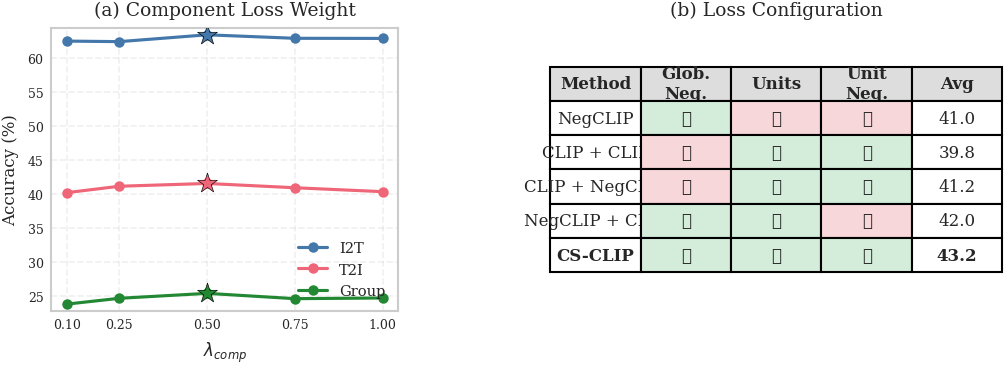


Figures saved to ../paper_figures/


In [9]:
# =============================================================================
# COMBINED FIGURE: Both ablations side by side
# =============================================================================

fig_width = plt.rcParams["figure.figsize"][0]  # Full width
fig = plt.figure(figsize=(fig_width, 2.5))

# Create grid: line plot on left, table on right
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.3], wspace=0.3)

# ---- Left: Component Lambda Line Plot ----
ax1 = fig.add_subplot(gs[0])

for metric in ['I2T', 'T2I', 'Group']:
    scores = comp_summary_df[metric].values * 100
    ax1.plot(lambda_values, scores, 'o-', color=colors[metric], 
             label=metric, linewidth=1.5, markersize=4)
    ax1.scatter([lambda_values[baseline_idx]], [scores[baseline_idx]], 
                marker='*', s=100, color=colors[metric], zorder=10, 
                edgecolor='black', linewidth=0.3)

ax1.set_xlabel(r'$\lambda_{comp}$')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(lambda_values)
ax1.legend(loc='lower right', fontsize=7, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_title('(a) Component Loss Weight', fontsize=9)

y_min = comp_summary_df[['I2T', 'T2I', 'Group']].min().min() * 100 - 1
y_max = comp_summary_df[['I2T', 'T2I', 'Group']].max().max() * 100 + 1
ax1.set_ylim(y_min, y_max)

# ---- Right: Loss Configuration Table ----
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')

# Simplified table for combined figure
col_labels_short = ['Method', 'Glob.\nNeg.', 'Units', 'Unit\nNeg.', 'Avg']

cell_text_short = []
cell_colors_short = []

for _, row in table_df.iterrows():
    avg = (float(row['I2T']) + float(row['T2I']) + float(row['Group'])) / 3
    row_text = [
        row['Model'],
        row['Global Neg.'],
        row['Units'],
        row['Unit Neg.'],
        f'{avg:.1f}'
    ]
    cell_text_short.append(row_text)
    
    row_colors = ['white']
    for val in [row['Global Neg.'], row['Units'], row['Unit Neg.']]:
        if val == '✓':
            row_colors.append('#d4edda')
        else:
            row_colors.append('#f8d7da')
    row_colors.append('white')
    cell_colors_short.append(row_colors)

table2 = ax2.table(
    cellText=cell_text_short,
    colLabels=col_labels_short,
    cellColours=cell_colors_short,
    colColours=[header_color] * len(col_labels_short),
    loc='center',
    cellLoc='center'
)

table2.auto_set_font_size(False)
table2.set_fontsize(8)
table2.scale(1.0, 1.4)

# Bold CS-CLIP row and header
for j in range(len(col_labels_short)):
    table2[(len(cell_text_short), j)].set_text_props(fontweight='bold')
    table2[(0, j)].set_text_props(fontweight='bold')

ax2.set_title('(b) Loss Configuration', fontsize=9)

plt.savefig('../paper_figures/ablation_combined.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("\nFigures saved to ../paper_figures/")

In [10]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

print("="*60)
print("SUMMARY")
print("="*60)

print("\n(a) Component Loss Weight Ablation:")
print(f"    Best λ_comp: {lambda_values[comp_summary_df['Average'].argmax()]} (Avg: {comp_summary_df['Average'].max()*100:.1f}%)")
print(f"    Baseline λ_comp=0.5: {comp_summary_df.loc['λ=0.5', 'Average']*100:.1f}%")

print("\n(b) Loss Configuration Ablation:")
print("    Method Ranking by Average:")
for model in loss_summary_df.sort_values('Average', ascending=False).index:
    avg = loss_summary_df.loc[model, 'Average'] * 100
    cfg = LOSS_CONFIG_MODELS[model]
    flags = f"[Global:{'+' if cfg['global_neg'] else '-'}, Units:{'+' if cfg['units'] else '-'}, UnitNeg:{'+' if cfg['unit_neg'] else '-'}]"
    marker = " ★" if cfg.get('is_baseline', False) else ""
    print(f"    {model:20s}: {avg:.1f}% {flags}{marker}")

SUMMARY

(a) Component Loss Weight Ablation:
    Best λ_comp: 0.5 (Avg: 43.4%)
    Baseline λ_comp=0.5: 43.4%

(b) Loss Configuration Ablation:
    Method Ranking by Average:
    CS-CLIP             : 43.2% [Global:+, Units:+, UnitNeg:+] ★
    NegCLIP + CLIP      : 42.1% [Global:+, Units:+, UnitNeg:-]
    CLIP + NegCLIP      : 41.2% [Global:-, Units:+, UnitNeg:+]
    NegCLIP             : 41.0% [Global:+, Units:-, UnitNeg:-]
    CLIP + CLIP         : 39.8% [Global:-, Units:+, UnitNeg:+]
    CLIP Fine-tuning    : 39.4% [Global:-, Units:-, UnitNeg:-]
